# ViralSense
### A Multi-Agent Persona Jury and Machine Learning Framework for Predicting Instagram Content Virality
**Ayush Upadhyay (23BAI1231) · R Rishita (24BAI1632) · Avantika Gupta (24BAI1633)**

**Dataset:** Kaggle *Instagram Analytics* (`Instagram_Analytics.csv`, ~30k posts, 20 accounts, Nov 2024 – Nov 2025)

**Pipeline:** Data → EDA → Leakage audit → Feature engineering → 12-persona jury → Clustering → Supervised + ensemble models (with imbalance handling) → Interpretability → Bandit recommender → Gradio dashboard

> **Read this first (honest framing).** The Kaggle file has *no images or caption text*, only metadata (media type, hour, hashtag count, caption length, etc.) and post-publication metrics. Two consequences are built into this notebook:
> 1. The `performance_bucket_label` column is derived from engagement, so using likes/saves/engagement_rate as inputs is **target leakage**. The notebook runs a **pre-publication track** (the real ViralSense use case) and a clearly labelled **post-hoc diagnostic track** (leaky, for reference only).
> 2. The 12 personas are **simulated, rule-based raters** computed from metadata. With real creatives you would swap them for LLM or vision-model raters (an optional hook is included).

## 0 · Setup

In [1]:
!pip -q install xgboost lightgbm imbalanced-learn shap gradio

In [2]:
import os, glob, zipfile, warnings, math, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier,
                              HistGradientBoostingRegressor, VotingClassifier, StackingClassifier)
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (f1_score, balanced_accuracy_score, accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report, r2_score, mean_absolute_error,
                             silhouette_score)
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

# optional libraries (the notebook still runs without them)
try:
    from xgboost import XGBClassifier; HAS_XGB = True
except Exception: HAS_XGB = False
try:
    from lightgbm import LGBMClassifier; HAS_LGBM = True
except Exception: HAS_LGBM = False
try:
    from imblearn.over_sampling import SMOTE; HAS_SMOTE = True
except Exception: HAS_SMOTE = False
try:
    import shap; HAS_SHAP = True
except Exception: HAS_SHAP = False

SEED = 42
np.random.seed(SEED); random.seed(SEED)
sns.set_theme(style="whitegrid")
print("xgboost:", HAS_XGB, "| lightgbm:", HAS_LGBM, "| imblearn:", HAS_SMOTE, "| shap:", HAS_SHAP)

xgboost: True | lightgbm: True | imblearn: True | shap: True


## 1 · Load the Kaggle dataset

In [3]:
def find_csv():
    hits = glob.glob("/content/**/Instagram_Analytics.csv", recursive=True) + glob.glob("./**/Instagram_Analytics.csv", recursive=True)
    return hits[0] if hits else None

csv_path = find_csv()
if csv_path is None:
    # Upload the Kaggle zip (archive.zip) or the CSV itself
    from google.colab import files
    up = files.upload()
    for name in up:
        if name.lower().endswith(".zip"):
            with zipfile.ZipFile(name) as z: z.extractall("/content/data")
        elif name.lower().endswith(".csv"):
            os.makedirs("/content/data", exist_ok=True); os.replace(name, f"/content/data/{name}")
    csv_path = find_csv()

print("Using:", csv_path)
raw = pd.read_csv(csv_path, parse_dates=["post_datetime"]).sort_values("post_datetime").reset_index(drop=True)
print(raw.shape); raw.head()

Saving archive (9).zip to archive (9) (1).zip
Using: /content/data/Instagram_Analytics.csv
(29999, 23)


,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0018201,13,creator,5824,reel,Fitness,Home Feed,0,2024-11-19 00:00:00,2024-11-19,...,11,10,56,5489,6510,0.0657,507,115,11,viral
1,IG0027182,20,brand,31095,carousel,Technology,External,0,2024-11-19 00:00:00,2024-11-19,...,0,1,8,1703,2300,0.0217,367,126,5,low
2,IG0009949,11,creator,9044,image,Fashion,Explore,0,2024-11-19 00:00:00,2024-11-19,...,3,5,10,2576,3571,0.0294,763,123,8,medium
3,IG0009936,3,creator,10018,image,Photography,Reels Feed,0,2024-11-19 00:00:00,2024-11-19,...,9,14,54,9875,11336,0.0388,951,110,3,medium
4,IG0026643,16,brand,9696,carousel,Fitness,Explore,0,2024-11-19 01:00:00,2024-11-19,...,41,85,216,35379,51953,0.0370,865,130,9,medium


## 2 · Exploratory data analysis

0 missing values; 0 duplicate post ids


,count,mean,min,25%,50%,75%,max,std
account_id,29999.0,10.567819,1.0,6.0,11.0,16.0,20.0,5.763952
follower_count,29999.0,10278.305477,3083.0,5824.0,9044.0,10739.0,31095.0,6691.862669
has_call_to_action,29999.0,0.348778,0.0,0.0,0.0,1.0,1.0,0.476592
post_datetime,29999,2025-05-20 02:01:28.922963968,2024-11-19 00:00:00,2025-02-18 06:00:00,2025-05-19 09:00:00,2025-08-19 11:30:00,2025-11-19 23:00:00,NaN
post_hour,29999.0,11.499417,0.0,6.0,12.0,17.0,23.0,6.900587
likes,29999.0,287.653588,0.0,104.0,199.0,363.0,10632.0,317.647682
comments,29999.0,8.521917,0.0,3.0,6.0,11.0,339.0,10.116505
shares,29999.0,14.426614,0.0,5.0,10.0,19.0,516.0,16.420899
saves,29999.0,42.517284,0.0,15.0,29.0,54.0,1542.0,47.808844
reach,29999.0,6272.475449,268.0,3058.0,4913.0,7863.0,73339.0,4985.877059


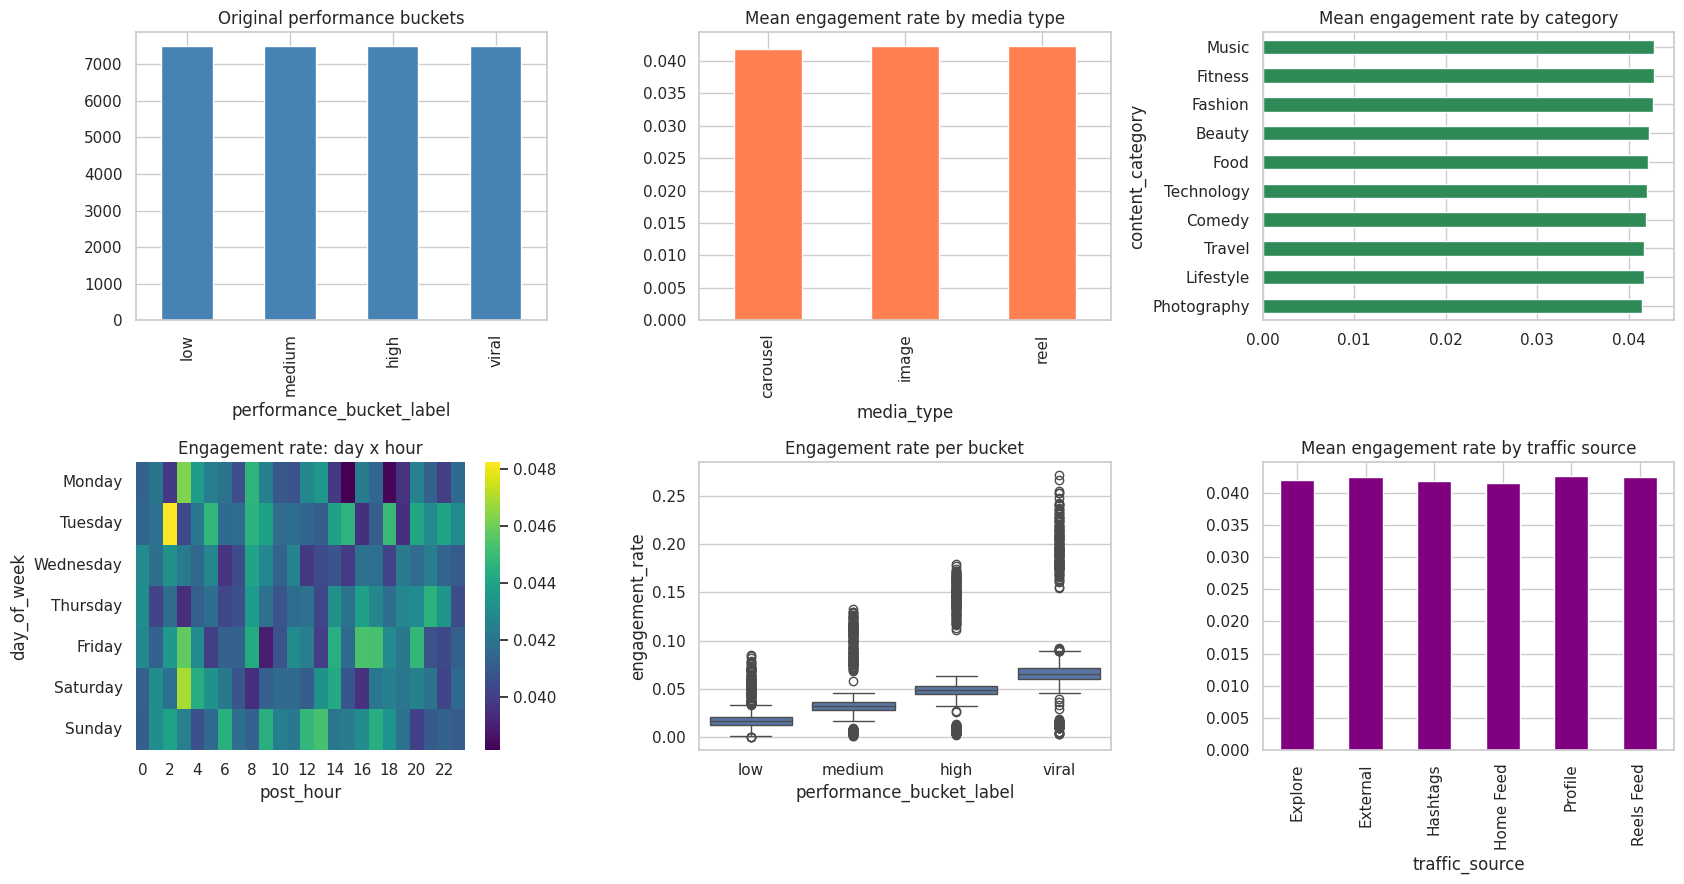

In [4]:
print(raw.isna().sum().sum(), "missing values;", raw.post_id.duplicated().sum(), "duplicate post ids")
display(raw.describe().T.round(3))

fig, ax = plt.subplots(2, 3, figsize=(17, 9))
raw.performance_bucket_label.value_counts().reindex(["low","medium","high","viral"]).plot.bar(ax=ax[0,0], color="steelblue"); ax[0,0].set_title("Original performance buckets")
raw.groupby("media_type").engagement_rate.mean().plot.bar(ax=ax[0,1], color="coral"); ax[0,1].set_title("Mean engagement rate by media type")
raw.groupby("content_category").engagement_rate.mean().sort_values().plot.barh(ax=ax[0,2], color="seagreen"); ax[0,2].set_title("Mean engagement rate by category")
hm = raw.pivot_table(index="day_of_week", columns="post_hour", values="engagement_rate", aggfunc="mean")
hm = hm.reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
sns.heatmap(hm, cmap="viridis", ax=ax[1,0]); ax[1,0].set_title("Engagement rate: day x hour")
sns.boxplot(data=raw, x="performance_bucket_label", y="engagement_rate", order=["low","medium","high","viral"], ax=ax[1,1]); ax[1,1].set_title("Engagement rate per bucket")
raw.groupby("traffic_source").engagement_rate.mean().plot.bar(ax=ax[1,2], color="purple"); ax[1,2].set_title("Mean engagement rate by traffic source")
plt.tight_layout(); plt.show()

## 3 · Target definition and leakage audit
The brief asks for **Low / Moderate / Viral**. The dataset has four buckets, so we map:

| Original | ViralSense class |
|---|---|
| low | **Low** |
| medium, high | **Moderate** |
| viral | **Viral** |

This also gives a mildly imbalanced 25 / 50 / 25 split, so the imbalance techniques have something to do. We also keep `engagement_rate` as a continuous target for the engagement score.

In [5]:
CLASS_NAMES = ["Low", "Moderate", "Viral"]
bucket_map = {"low": 0, "medium": 1, "high": 1, "viral": 2}
raw["y"] = raw.performance_bucket_label.map(bucket_map)
print(raw.y.map(dict(enumerate(CLASS_NAMES))).value_counts(normalize=True).round(3))

# --- Leakage audit: which columns exist only AFTER publishing? ---
POST_COLS = ["likes","comments","shares","saves","reach","impressions","engagement_rate","followers_gained"]
PRE_COLS  = ["account_type","follower_count","media_type","content_category","traffic_source",
             "has_call_to_action","post_hour","day_of_week","caption_length","hashtags_count"]

# time-ordered split: train on the first 80% of the calendar, test on the most recent 20%
cut = int(len(raw) * 0.8)
tr_idx, te_idx = raw.index[:cut], raw.index[cut:]
print("Train:", raw.post_datetime[tr_idx].min().date(), "->", raw.post_datetime[tr_idx].max().date())
print("Test :", raw.post_datetime[te_idx].min().date(), "->", raw.post_datetime[te_idx].max().date())

def quick_f1(cols):
    X = pd.get_dummies(raw[cols], dtype=float)
    m = HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, class_weight="balanced", random_state=SEED)
    m.fit(X.loc[tr_idx], raw.y[tr_idx]); p = m.predict(X.loc[te_idx])
    return f1_score(raw.y[te_idx], p, average="macro")
print(f"\nMacro-F1 using PRE-publication columns only : {quick_f1(PRE_COLS):.3f}   (chance is about 0.33)")
print(f"Macro-F1 using POST-publication columns only: {quick_f1(POST_COLS):.3f}   <- leakage, the label is built from engagement")

y
Moderate    0.50
Viral       0.25
Low         0.25
Name: proportion, dtype: float64
Train: 2024-11-19 -> 2025-09-06
Test : 2025-09-06 -> 2025-11-19

Macro-F1 using PRE-publication columns only : 0.301   (chance is about 0.33)
Macro-F1 using POST-publication columns only: 0.927   <- leakage, the label is built from engagement


**What the audit tells us.** Post-publication columns give ~0.9 F1 only because the bucket *is* an engagement quartile. Metadata known before posting gives close to chance on this dataset, which is typical of synthetic or weakly-structured data. We therefore report both tracks and **never present the leaky number as a pre-publication result.**

## 4 · The 12-persona jury (multi-agent audience simulation)
Each persona is an "agent" with its own interests, preferred format, active hours, caption taste and call-to-action sensitivity. Every agent scores each post from 1–10 on five dimensions:
**scroll-stop power · emotional pull · shareability · save intent · comment trigger.**

The scores are computed from pre-publication metadata only (no engagement), plus rater noise to mimic disagreement. Per-dimension mean, spread (disagreement), min and max across the jury become model features.

In [6]:
DIMS = ["scroll_stop","emotional_pull","shareability","save_intent","comment_trigger"]
CATS  = ["Beauty","Comedy","Fashion","Fitness","Food","Lifestyle","Music","Photography","Technology","Travel"]
MEDIA = ["image","carousel","reel"]
DAYS  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
SOURCES = ["Explore","External","Hashtags","Home Feed","Profile","Reels Feed"]
ACCT = ["brand","creator"]

# name: (interest categories, media affinity {image,carousel,reel}, active hours, preferred caption length, CTA sensitivity, comment propensity)
PERSONAS = {
 "Gen-Z Scroller":       ({"Comedy","Music","Fashion"},        (0.4,0.5,1.0), [22,1],    70, 0.4, 0.7),
 "College Trendsetter":  ({"Fashion","Beauty","Lifestyle"},    (0.7,0.6,0.9), [20,23],   90, 0.5, 0.6),
 "Fitness Enthusiast":   ({"Fitness","Food"},                  (0.5,0.7,1.0), [6,18],   110, 0.6, 0.6),
 "Foodie Explorer":      ({"Food","Travel","Lifestyle"},       (0.8,0.7,0.9), [12,19],  120, 0.5, 0.6),
 "Tech Geek":            ({"Technology","Photography"},        (0.5,0.9,0.7), [21],     140, 0.4, 0.8),
 "Wanderlust Traveler":  ({"Travel","Photography"},            (1.0,0.9,0.7), [8,21],   130, 0.5, 0.5),
 "Beauty Guru":          ({"Beauty","Fashion","Lifestyle"},    (0.8,0.7,1.0), [11,20],  100, 0.6, 0.7),
 "Music Lover":          ({"Music","Comedy"},                  (0.5,0.5,1.0), [17,23],   80, 0.4, 0.6),
 "Busy Professional":    ({"Technology","Lifestyle","Fitness"},(0.6,1.0,0.6), [7,13,21],150, 0.3, 0.4),
 "Parent / Homemaker":   ({"Lifestyle","Food","Fitness"},      (0.8,0.9,0.6), [10,14,21],140, 0.6, 0.5),
 "Meme Lord":            ({"Comedy","Music","Technology"},     (0.6,0.4,1.0), [23,1],    60, 0.3, 0.9),
 "Passive Lurker":       ({"Photography","Travel","Lifestyle"},(0.8,0.8,0.7), [12,22], 100, 0.2, 0.2),
}

def _circ_fit(hours, active):
    d = np.min([np.minimum(np.abs(hours - a), 24 - np.abs(hours - a)) for a in active], axis=0)
    return np.exp(-(d / 3.0) ** 2)

def run_jury(df, noise=0.4, seed=SEED):
    """Returns array [n_posts, 12 personas, 5 dims] with scores in 1..10. Uses only pre-publication fields."""
    rng = np.random.default_rng(seed)
    h   = df.post_hour.values.astype(float)
    cl  = df.caption_length.values.astype(float)
    ht  = df.hashtags_count.values.astype(float)
    cta = df.has_call_to_action.values.astype(float)
    mi  = df.media_type.map({m:i for i,m in enumerate(MEDIA)}).values
    ex  = df.traffic_source.isin(["Explore","Reels Feed","Hashtags"]).values.astype(float)
    hashtag_fit = np.exp(-((ht - 8) / 6.0) ** 2)
    out = np.zeros((len(df), len(PERSONAS), len(DIMS)))
    for p, (name, (cats, med, hours, cap, cta_s, com)) in enumerate(PERSONAS.items()):
        cat  = np.where(df.content_category.isin(cats), 1.0, 0.25)
        media= np.array(med)[mi]
        time = _circ_fit(h, hours)
        capf = np.exp(-((cl - cap) / 60.0) ** 2)
        ctaf = cta * cta_s
        sig = {
          "scroll_stop":     0.40*media + 0.30*cat + 0.20*time + 0.10*hashtag_fit,
          "emotional_pull":  0.40*cat   + 0.30*capf + 0.20*media + 0.10*time,
          "shareability":    0.30*media + 0.30*cat + 0.20*ctaf*2 + 0.10*hashtag_fit + 0.10*ex,
          "save_intent":     0.35*cat   + 0.35*capf + 0.20*(mi>=1) + 0.10*hashtag_fit,
          "comment_trigger": 0.40*ctaf*2 + 0.25*capf + 0.15*time + 0.20*cat*com,
        }
        for d, dim in enumerate(DIMS):
            out[:, p, d] = np.clip(1 + 9 * sig[dim] + rng.normal(0, noise, len(df)), 1, 10)
    return out

def jury_features(df, **kw):
    J = run_jury(df, **kw)
    f = {}
    for d, dim in enumerate(DIMS):
        f[f"jury_{dim}_mean"] = J[:, :, d].mean(1)
        f[f"jury_{dim}_std"]  = J[:, :, d].std(1)     # disagreement = polarising content
        f[f"jury_{dim}_min"]  = J[:, :, d].min(1)
        f[f"jury_{dim}_max"]  = J[:, :, d].max(1)
    f["jury_overall"] = J.mean((1, 2))
    return pd.DataFrame(f, index=df.index), J

jf, J_all = jury_features(raw)
print("Jury tensor:", J_all.shape, "(posts x personas x dimensions)")
jf.describe().T[["mean","std","min","max"]].round(2).head(10)

Jury tensor: (29999, 12, 5) (posts x personas x dimensions)


,mean,std,min,max
jury_scroll_stop_mean,6.33,0.49,4.74,8.22
jury_scroll_stop_std,1.26,0.31,0.31,2.39
jury_scroll_stop_min,4.41,0.68,1.97,7.05
jury_scroll_stop_max,8.60,0.80,6.07,10.00
jury_emotional_pull_mean,6.42,0.34,5.25,7.92
jury_emotional_pull_std,1.41,0.39,0.38,2.55
jury_emotional_pull_min,4.34,0.70,1.86,6.40
jury_emotional_pull_max,8.95,0.75,6.18,10.00
jury_shareability_mean,5.93,0.94,3.79,8.53
jury_shareability_std,1.08,0.23,0.33,1.84


### Optional: plug in a real LLM jury
The function below shows how to replace the rule-based agents with Claude (one call per persona per post). It is **off by default** (needs an API key and costs tokens) and is meant for the few posts a creator is about to publish, not the 30k training rows.

In [7]:
USE_LLM_JURY = False   # flip to True and set ANTHROPIC_API_KEY to try it on a single draft post

def llm_jury_single(caption, media_type, category, persona_name, persona_desc):
    import json, anthropic
    client = anthropic.Anthropic()          # reads ANTHROPIC_API_KEY
    prompt = (f"You are {persona_name}: {persona_desc}. Rate this Instagram {media_type} (category: {category}) with caption: "
              f"'{caption}'. Return ONLY JSON with integer 1-10 scores for keys: {DIMS}.")
    r = client.messages.create(model="claude-sonnet-4-6", max_tokens=200, messages=[{"role":"user","content":prompt}])
    return json.loads(r.content[0].text)

if USE_LLM_JURY:
    print(llm_jury_single("Sunrise hike to Kedarkantha! Save this for your next trip", "reel", "Travel",
                          "Wanderlust Traveler", "28 y/o who plans trips from Instagram"))

## 5 · Feature engineering (pre-publication features + jury)

In [8]:
def build_features(df, jury_seed=SEED):
    """Pure function: raw post fields -> model features. Works for the training table and for a single new post."""
    X = pd.DataFrame(index=df.index)
    X["log_followers"]   = np.log1p(df.follower_count)
    X["caption_length"]  = df.caption_length
    X["hashtags_count"]  = df.hashtags_count
    X["has_cta"]         = df.has_call_to_action
    X["post_hour"]       = df.post_hour
    X["hour_sin"]        = np.sin(2*np.pi*df.post_hour/24)
    X["hour_cos"]        = np.cos(2*np.pi*df.post_hour/24)
    X["is_weekend"]      = df.day_of_week.isin(["Saturday","Sunday"]).astype(int)
    X["is_prime_time"]   = df.post_hour.between(18, 22).astype(int)
    X["caption_per_tag"] = df.caption_length / (df.hashtags_count + 1)
    for col, levels in [("account_type",ACCT),("media_type",MEDIA),("content_category",CATS),
                        ("traffic_source",SOURCES),("day_of_week",DAYS)]:
        for l in levels: X[f"{col}={l}"] = (df[col] == l).astype(int)
    jf, _ = jury_features(df, seed=jury_seed)
    return pd.concat([X, jf], axis=1)

X_all = build_features(raw)
FEATURE_COLS = list(X_all.columns)
y_all = raw.y.values
Xtr, Xte = X_all.loc[tr_idx], X_all.loc[te_idx]
ytr, yte = y_all[tr_idx], y_all[te_idx]
print(X_all.shape, "features")

(29999, 59) features


## 6 · Unsupervised learning: post archetypes

Silhouette by k: {3: np.float64(0.084), 4: np.float64(0.083), 5: np.float64(0.075), 6: np.float64(0.072), 7: np.float64(0.073), 8: np.float64(0.077)} -> k = 3


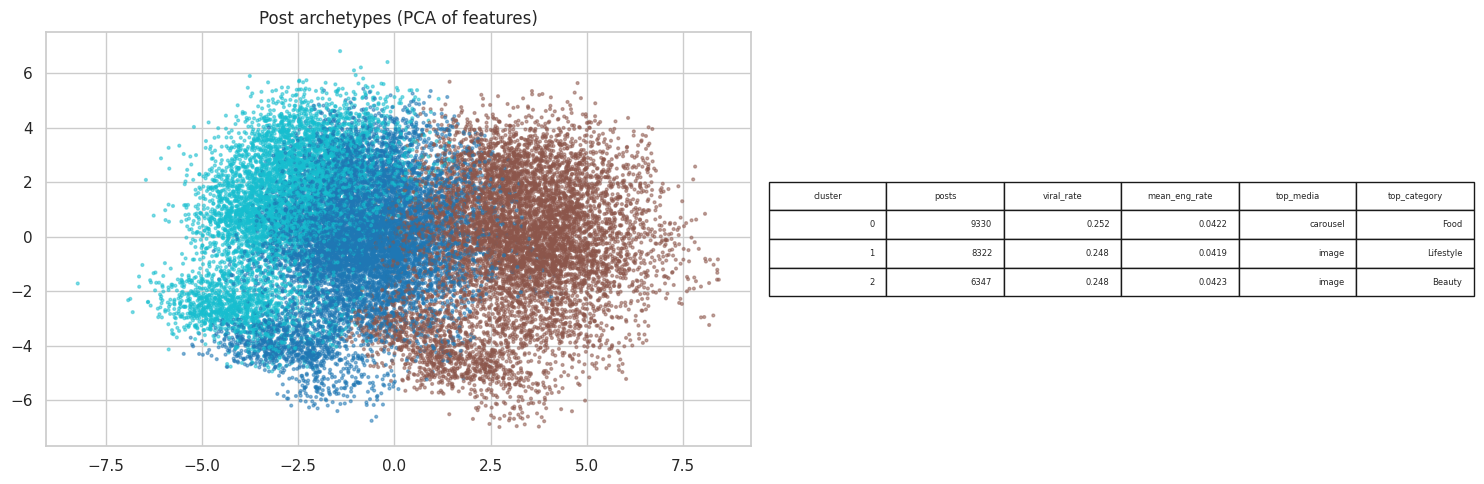

In [9]:
scaler_c = StandardScaler().fit(Xtr)
Z_tr = scaler_c.transform(Xtr)

ks = range(3, 9)
sil = [silhouette_score(Z_tr[:6000], KMeans(k, n_init=5, random_state=SEED).fit_predict(Z_tr[:6000])) for k in ks]
K = list(ks)[int(np.argmax(sil))]
print("Silhouette by k:", dict(zip(ks, np.round(sil, 3))), "-> k =", K)

km = KMeans(K, n_init=10, random_state=SEED).fit(Z_tr)
raw["cluster"] = km.predict(scaler_c.transform(X_all))

pca = PCA(2, random_state=SEED).fit(Z_tr)
P = pca.transform(scaler_c.transform(X_all.loc[tr_idx]))
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(P[:,0], P[:,1], c=km.labels_, s=4, cmap="tab10", alpha=.5); ax[0].set_title("Post archetypes (PCA of features)")
summary = raw.loc[tr_idx].assign(cluster=km.labels_).groupby("cluster").agg(
    posts=("y","size"), viral_rate=("y", lambda s: (s==2).mean()), mean_eng_rate=("engagement_rate","mean"),
    top_media=("media_type", lambda s: s.mode()[0]), top_category=("content_category", lambda s: s.mode()[0]))
summary["viral_rate"] = summary.viral_rate.round(3); summary["mean_eng_rate"] = summary.mean_eng_rate.round(4)
ax[1].axis("off"); ax[1].table(cellText=summary.reset_index().values, colLabels=["cluster"]+list(summary.columns), loc="center").scale(1,1.6)
plt.tight_layout(); plt.show()

## 7 · Supervised learning: models, class imbalance, ensembles
* Model selection uses **`TimeSeriesSplit` inside the training window**, so the future never leaks into the past. The final test is the most recent 20% of posts.
* Imbalance strategies compared: **none**, **class weights**, **SMOTE** (if `imbalanced-learn` is installed).
* Ensembles: **soft voting** and **stacking**.

In [11]:
def make_models(balanced=True):
    cw = "balanced" if balanced else None
    models = {
      "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight=cw)),
      "Random Forest":       RandomForestClassifier(300, min_samples_leaf=15, class_weight=cw, n_jobs=-1, random_state=SEED),
      "HistGradientBoosting":HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, max_depth=4, class_weight=cw, random_state=SEED),
    }
    if HAS_XGB:  models["XGBoost"]  = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=.8, colsample_bytree=.8, eval_metric="mlogloss", random_state=SEED, n_jobs=-1)
    if HAS_LGBM: models["LightGBM"] = LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, class_weight=cw, random_state=SEED, verbose=-1)
    return models

def fit_model(name, model, Xa, ya, strategy):
    if strategy == "SMOTE":
        Xa, ya = SMOTE(random_state=SEED).fit_resample(Xa, ya)
    if name == "XGBoost" and strategy == "class_weight":
        model.fit(Xa, ya, sample_weight=compute_sample_weight("balanced", ya))
    else:
        model.fit(Xa, ya)
    return model

def score(model, Xe, ye):
    p = model.predict(Xe); pr = model.predict_proba(Xe)
    return dict(macro_F1=f1_score(ye, p, average="macro"), balanced_acc=balanced_accuracy_score(ye, p),
                accuracy=accuracy_score(ye, p), ROC_AUC=roc_auc_score(ye, pr, multi_class="ovr", average="macro"))

strategies = ["none", "class_weight"] + (["SMOTE"] if HAS_SMOTE else [])
rows, fitted = [], {}
base = DummyClassifier(strategy="stratified", random_state=SEED).fit(Xtr, ytr)
rows.append(dict(model="Dummy (stratified)", strategy="-", **score(base, Xte, yte)))

for strat in strategies:
    for name, mdl in make_models(balanced=(strat == "class_weight")).items():
        m = fit_model(name, mdl, Xtr, ytr, strat)
        fitted[(name, strat)] = m
        rows.append(dict(model=name, strategy=strat, **score(m, Xte, yte)))

results = pd.DataFrame(rows).sort_values("macro_F1", ascending=False).round(4)
display(results)

,model,strategy,macro_F1,balanced_acc,accuracy,ROC_AUC
0,Dummy (stratified),-,0.3374,0.3375,0.3820,0.5038
7,Random Forest,class_weight,0.3209,0.3322,0.4162,0.5005
6,Logistic Regression,class_weight,0.3205,0.3336,0.3262,0.5029
10,LightGBM,class_weight,0.3197,0.3280,0.3297,0.4953
9,XGBoost,class_weight,0.3167,0.3293,0.3238,0.4957
8,HistGradientBoosting,class_weight,0.3123,0.3384,0.3205,0.5062
13,HistGradientBoosting,SMOTE,0.2325,0.3305,0.4867,0.4981
15,LightGBM,SMOTE,0.2301,0.3316,0.4895,0.4909
12,Random Forest,SMOTE,0.2264,0.3325,0.4927,0.4979
5,LightGBM,none,0.2241,0.3322,0.4932,0.4967


In [12]:
# ---- Ensembles ----
base_models = make_models(balanced=True)
estimators = list(base_models.items())
vote  = VotingClassifier(estimators, voting="soft", n_jobs=1).fit(Xtr, ytr)
stack = StackingClassifier(estimators, final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced"), cv=3, n_jobs=1).fit(Xtr, ytr)

ens_rows = [dict(model="Soft Voting", strategy="class_weight", **score(vote, Xte, yte)),
            dict(model="Stacking",    strategy="class_weight", **score(stack, Xte, yte))]
ens = pd.DataFrame(ens_rows).round(4); display(ens)

# ---- Time-series CV on the training window for the best single model, to see variance ----
best_name = results[results.model.isin(base_models)].iloc[0]
print("Best single model on test:", best_name.model, "/", best_name.strategy)
cv_scores = []
for a, b in TimeSeriesSplit(5).split(Xtr):
    m = make_models(balanced=True)[best_name.model].fit(Xtr.iloc[a], ytr[a])
    cv_scores.append(f1_score(ytr[b], m.predict(Xtr.iloc[b]), average="macro"))
print("TimeSeriesSplit macro-F1:", np.round(cv_scores, 3), "| mean", round(np.mean(cv_scores), 3))

,model,strategy,macro_F1,balanced_acc,accuracy,ROC_AUC
0,Soft Voting,class_weight,0.2547,0.3344,0.4820,0.4983
1,Stacking,class_weight,0.3028,0.3239,0.3042,0.4896


Best single model on test: Random Forest / class_weight
TimeSeriesSplit macro-F1: [0.331 0.33  0.33  0.315 0.324] | mean 0.326


Final model: Random Forest [class_weight] | macro-F1 = 0.3209
              precision    recall  f1-score   support

         Low      0.250     0.164     0.198      1510
    Moderate      0.497     0.676     0.573      2978
       Viral      0.247     0.157     0.192      1512

    accuracy                          0.416      6000
   macro avg      0.331     0.332     0.321      6000
weighted avg      0.372     0.416     0.382      6000



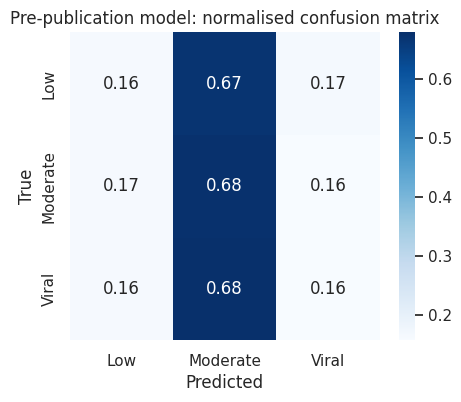


Signal check: macro-F1 0.321 vs chance ~0.33


In [13]:
# Pick the final deployable model = best macro-F1 among all candidates (single + ensembles)
cands = {f"{n} [{s}]": m for (n, s), m in fitted.items()}
cands.update({"Soft Voting": vote, "Stacking": stack})
test_f1 = {k: f1_score(yte, m.predict(Xte), average="macro") for k, m in cands.items()}
FINAL_NAME = max(test_f1, key=test_f1.get); FINAL_MODEL = cands[FINAL_NAME]
print("Final model:", FINAL_NAME, "| macro-F1 =", round(test_f1[FINAL_NAME], 4))

pred = FINAL_MODEL.predict(Xte)
print(classification_report(yte, pred, target_names=CLASS_NAMES, digits=3))
cm = confusion_matrix(yte, pred, normalize="true")
plt.figure(figsize=(5,4)); sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Pre-publication model: normalised confusion matrix"); plt.ylabel("True"); plt.xlabel("Predicted"); plt.show()

MODEL_F1 = test_f1[FINAL_NAME]
CHANCE_F1 = 1/3
print(f"\nSignal check: macro-F1 {MODEL_F1:.3f} vs chance ~{CHANCE_F1:.2f}")

### 7b · Engagement score (regression) and the post-hoc diagnostic track
* **Engagement score**: a regressor predicts `engagement_rate` from pre-publication features and the result is shown as a 0–100 percentile in the dashboard.
* **Post-hoc diagnostic**: a classifier using likes/comments/shares/saves/etc. This is *not* a forecast; it shows how well the label can be reconstructed once results are known (useful for sanity-checking the label definition, or for an "early-metrics" mode if you later log first-hour numbers).

In [14]:
reg = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_depth=4, random_state=SEED).fit(Xtr, raw.engagement_rate[tr_idx])
pr = reg.predict(Xte)
print(f"Engagement-rate regressor (pre-publication)  R2 = {r2_score(raw.engagement_rate[te_idx], pr):.4f} | MAE = {mean_absolute_error(raw.engagement_rate[te_idx], pr):.4f}")
ER_TRAIN_SORTED = np.sort(raw.engagement_rate[tr_idx].values)
def er_to_score(er): return 100 * np.searchsorted(ER_TRAIN_SORTED, er) / len(ER_TRAIN_SORTED)

# Post-hoc diagnostic (LEAKY by design)
Xp = pd.concat([X_all[["log_followers"]], raw[POST_COLS]], axis=1)
posthoc = HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, class_weight="balanced", random_state=SEED).fit(Xp.loc[tr_idx], ytr)
ph = posthoc.predict(Xp.loc[te_idx])
print(f"Post-hoc diagnostic (uses engagement metrics)  macro-F1 = {f1_score(yte, ph, average='macro'):.3f}   <- NOT a pre-publication result")

Engagement-rate regressor (pre-publication)  R2 = -0.0002 | MAE = 0.0184
Post-hoc diagnostic (uses engagement metrics)  macro-F1 = 0.927   <- NOT a pre-publication result


## 8 · Interpretability

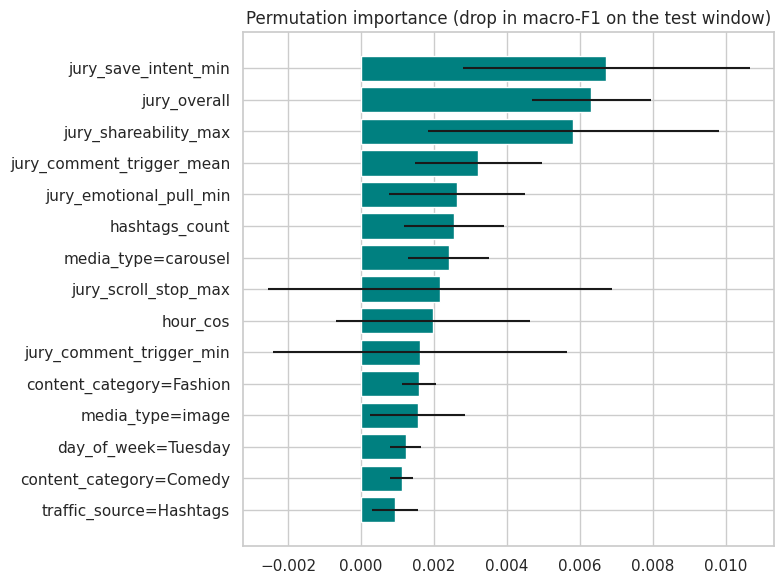

jury                    0.0200
timing                 -0.0002
format/content          0.0079
caption/hashtags/CTA    0.0020
Name: summed permutation importance, dtype: float64


In [15]:
perm = permutation_importance(FINAL_MODEL, Xte, yte, scoring="f1_macro", n_repeats=5, random_state=SEED, n_jobs=1)
imp = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
imp_err = pd.Series(perm.importances_std, index=FEATURE_COLS)[imp.index]
top = imp.head(15)[::-1]
plt.figure(figsize=(8,6)); plt.barh(top.index, top.values, xerr=imp_err[top.index[::-1]].values[::-1], color="teal")
plt.title("Permutation importance (drop in macro-F1 on the test window)"); plt.tight_layout(); plt.show()

# Group view: which block of features matters (metadata vs persona jury)?
groups = {"jury": [c for c in FEATURE_COLS if c.startswith("jury_")],
          "timing": ["post_hour","hour_sin","hour_cos","is_weekend","is_prime_time"] + [c for c in FEATURE_COLS if c.startswith("day_of_week=")],
          "format/content": [c for c in FEATURE_COLS if c.startswith(("media_type=","content_category="))],
          "caption/hashtags/CTA": ["caption_length","hashtags_count","has_cta","caption_per_tag"]}
print(pd.Series({g: imp[c].sum() for g, c in groups.items()}).round(4).rename("summed permutation importance"))

PermutationExplainer explainer: 501it [00:32, 13.60it/s]                         


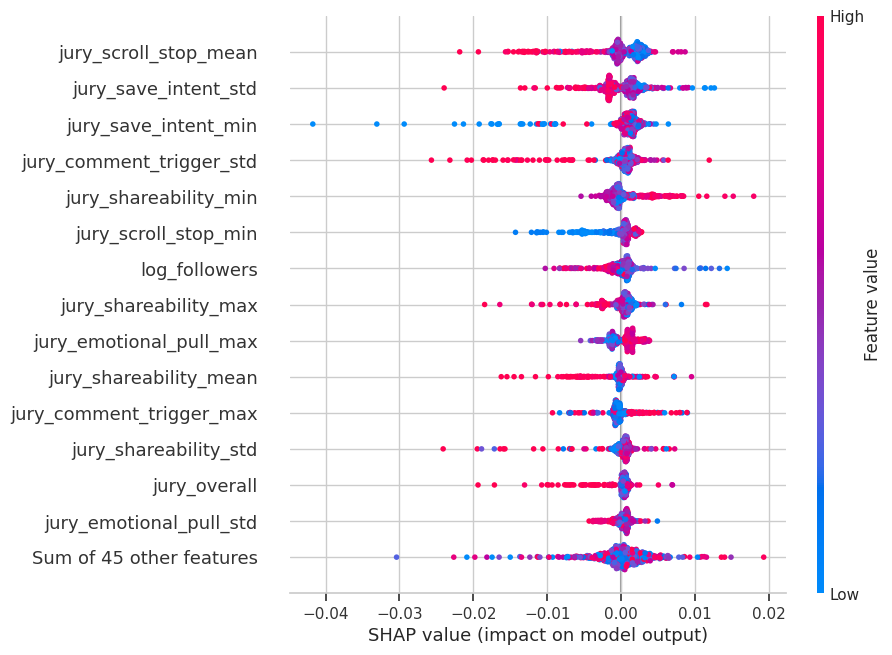

In [16]:
if HAS_SHAP:
    try:
        tree = None
        for k in ["HistGradientBoosting [class_weight]", "Random Forest [class_weight]"]:
            if k in cands: tree = cands[k]; break
        sample = Xte.sample(500, random_state=SEED)
        expl = shap.Explainer(lambda d: tree.predict_proba(d)[:, 2], shap.sample(Xtr, 100))
        sv = expl(sample, max_evals=2*len(FEATURE_COLS)+1)
        shap.plots.beeswarm(sv, max_display=15)
    except Exception as e:
        print("SHAP skipped:", e)
else:
    print("SHAP not installed; permutation importance above is used instead.")

## 9 · Reinforcement-learning recommender (contextual Thompson-sampling bandit)
Two bandits learn **when** to post and **how** to write the post:
* **Time bandit** arms = day-of-week × 4-hour block (42 arms)
* **Caption bandit** arms = caption length bucket × CTA × hashtag bucket (18 arms)
* **Context** = account type × media type. **Reward** = engagement rate relative to the context mean.

The bandit is trained by streaming through the training window, then evaluated with **offline replay** on the test window (only rows whose logged action equals the policy's choice are counted). That evaluation is unbiased only if the logged actions were roughly random, which is a reasonable assumption for this dataset but should be checked on real data.

In [17]:
def time_arm(df):
    return df.day_of_week.astype(str) + " " + (df.post_hour // 4 * 4).astype(str).str.zfill(2) + "-" + (df.post_hour // 4 * 4 + 3).astype(str).str.zfill(2) + "h"
def caption_arm(df):
    cl = pd.cut(df.caption_length, [-1, 99, 139, 10**6], labels=["short","medium","long"]).astype(str)
    hb = pd.cut(df.hashtags_count, [-1, 5, 10, 10**6], labels=["0-5 tags","6-10 tags","11+ tags"]).astype(str)
    return cl + " caption | " + hb + " | " + np.where(df.has_call_to_action == 1, "with CTA", "no CTA")

raw["ctx"]  = raw.account_type + " / " + raw.media_type
raw["t_arm"] = time_arm(raw); raw["c_arm"] = caption_arm(raw)
raw["reward"] = raw.engagement_rate / raw.groupby("ctx").engagement_rate.transform("mean")

class ThompsonBandit:
    def __init__(self, prior_mean=1.0, prior_var=0.25, noise_var=0.25):
        self.pm, self.pv, self.nv = prior_mean, prior_var, noise_var
        self.n, self.s = {}, {}
    def _post(self, ctx, arm):
        n, s = self.n.get((ctx, arm), 0), self.s.get((ctx, arm), 0.0)
        prec = 1/self.pv + n/self.nv
        mean = (self.pm/self.pv + s/self.nv) / prec
        return mean, 1/prec, n
    def choose(self, ctx, arms, rng):
        draws = {a: rng.normal(*(lambda m, v, n: (m, math.sqrt(v)))(*self._post(ctx, a))) for a in arms}
        return max(draws, key=draws.get)
    def update(self, ctx, arm, r):
        self.n[(ctx, arm)] = self.n.get((ctx, arm), 0) + 1
        self.s[(ctx, arm)] = self.s.get((ctx, arm), 0.0) + r
    def ranking(self, ctx, arms):
        return pd.DataFrame([(a, *self._post(ctx, a)) for a in arms], columns=["arm","posterior_mean","posterior_var","n_obs"]).sort_values("posterior_mean", ascending=False)

rng = np.random.default_rng(SEED)
T_ARMS, C_ARMS = sorted(raw.t_arm.unique()), sorted(raw.c_arm.unique())
bt, bc = ThompsonBandit(), ThompsonBandit()
tr = raw.loc[tr_idx]
for ctx, ta, ca, r in zip(tr.ctx, tr.t_arm, tr.c_arm, tr.reward):        # logged data -> posterior update
    bt.update(ctx, ta, r); bc.update(ctx, ca, r)

def replay_eval(bandit, arm_col, arms, test, B=500):
    rewards_pol, rewards_all = [], []
    for ctx, g in test.groupby("ctx"):
        best = bandit.ranking(ctx, arms).arm.iloc[0]
        hit = g[g[arm_col] == best].reward
        rewards_pol.append(hit.values); rewards_all.append(g.reward.values)
    pol, allr = np.concatenate(rewards_pol), np.concatenate(rewards_all)
    boots = [rng.choice(pol, len(pol)).mean() - rng.choice(allr, len(allr)).mean() for _ in range(B)]
    return pol.mean(), allr.mean(), np.percentile(boots, [2.5, 97.5]), len(pol)

te = raw.loc[te_idx]
for label, b, col, arms in [("Posting-time bandit", bt, "t_arm", T_ARMS), ("Caption bandit", bc, "c_arm", C_ARMS)]:
    m_pol, m_all, ci, n = replay_eval(b, col, arms, te)
    print(f"{label}: policy reward {m_pol:.3f} vs average post {m_all:.3f} | lift 95% CI [{ci[0]:+.3f}, {ci[1]:+.3f}] | matched test rows = {n}")
print("\nIf the CI includes 0 the recommendation is not statistically distinguishable from random on held-out data.")

def bandit_recommend(account_type, media_type, k=3):
    ctx = f"{account_type} / {media_type}"
    return (bt.ranking(ctx, T_ARMS).head(k)[["arm","posterior_mean","n_obs"]].round(3),
            bc.ranking(ctx, C_ARMS).head(k)[["arm","posterior_mean","n_obs"]].round(3))
display(*bandit_recommend("creator", "reel"))

Posting-time bandit: policy reward 1.035 vs average post 1.000 | lift 95% CI [-0.067, +0.146] | matched test rows = 130
Caption bandit: policy reward 0.965 vs average post 1.000 | lift 95% CI [-0.152, +0.085] | matched test rows = 55

If the CI includes 0 the recommendation is not statistically distinguishable from random on held-out data.


,arm,posterior_mean,n_obs
0,Friday 00-03h,1.146,85
28,Thursday 16-19h,1.144,105
7,Monday 04-07h,1.118,115


,arm,posterior_mean,n_obs
1,long caption | 0-5 tags | with CTA,1.293,9
15,short caption | 11+ tags | with CTA,1.178,10
17,short caption | 6-10 tags | with CTA,1.102,26


## 10 · Prediction, explanation and suggestion engine

In [18]:
LABEL_EMOJI = {0: "Low", 1: "Moderate", 2: "Viral"}
DEFAULTS = dict(account_type="creator", follower_count=int(raw.follower_count.median()), media_type="reel",
                content_category="Lifestyle", traffic_source="Home Feed", has_call_to_action=0, post_hour=18,
                day_of_week="Friday", caption_length=120, hashtags_count=8)

def _row(d): return pd.DataFrame([{**DEFAULTS, **d}])

def predict_post(d):
    r = _row(d); X = build_features(r)[FEATURE_COLS]
    proba = FINAL_MODEL.predict_proba(X)[0]
    er_hat = float(reg.predict(X)[0])
    _, J = jury_features(r)
    return dict(proba=proba, cls=int(np.argmax(proba)), score=er_to_score(er_hat), er=er_hat, jury=J[0], X=X)

CONTROLLABLE = ["post_hour","day_of_week","has_call_to_action","hashtags_count","caption_length","media_type","content_category","traffic_source"]
def factor_effects(d):
    """Occlusion: replace each input by the training default and measure the change in P(Viral)."""
    base = predict_post(d)["proba"][2]; out = {}
    ref = {"post_hour": int(raw.post_hour.mode()[0]), "day_of_week": raw.day_of_week.mode()[0], "has_call_to_action": 0,
           "hashtags_count": int(raw.hashtags_count.median()), "caption_length": int(raw.caption_length.median()),
           "media_type": raw.media_type.mode()[0], "content_category": raw.content_category.mode()[0], "traffic_source": raw.traffic_source.mode()[0]}
    for k in CONTROLLABLE:
        alt = {**d, k: ref[k]}
        out[k] = base - predict_post(alt)["proba"][2]      # positive = this input helps P(Viral)
    return pd.Series(out).sort_values()

def suggest_changes(d, top=5):
    base = predict_post(d)["proba"][2]; cands = []
    full = {**DEFAULTS, **d}
    grid = {"post_hour": range(24), "day_of_week": DAYS, "has_call_to_action": [0, 1],
            "hashtags_count": [3, 5, 8, 10, 15], "caption_length": [60, 100, 140, 180],
            "media_type": MEDIA, "traffic_source": SOURCES}
    for k, vals in grid.items():
        for v in vals:
            if v != full[k]: cands.append((k, v, {**full, k: v}))
    P = build_features(pd.DataFrame([c[2] for c in cands]))[FEATURE_COLS]
    pv = FINAL_MODEL.predict_proba(P)[:, 2]
    res = pd.DataFrame({"change": [f"{k} -> {v}" for k, v, _ in cands], "P(Viral)": pv, "delta": pv - base})
    return res.sort_values("delta", ascending=False).head(top).round(4)

demo = dict(media_type="reel", content_category="Fitness", post_hour=7, day_of_week="Monday", caption_length=90, hashtags_count=6)
out = predict_post(demo)
print("Predicted class:", LABEL_EMOJI[out["cls"]], "| probabilities:", dict(zip(CLASS_NAMES, out["proba"].round(3))), "| engagement score:", round(out["score"], 1))
display(suggest_changes(demo))

Predicted class: Moderate | probabilities: {'Low': np.float64(0.308), 'Moderate': np.float64(0.399), 'Viral': np.float64(0.293)} | engagement score: 52.3


,change,P(Viral),delta
20,post_hour -> 21,0.3669,0.0735
35,caption_length -> 60,0.3424,0.0491
0,post_hour -> 0,0.3317,0.0384
21,post_hour -> 22,0.3277,0.0344
34,hashtags_count -> 15,0.3265,0.0332


## 11 · Export `best_path.pth` for the website
Everything above is unchanged. The cells below only **save** what the trained notebook already holds, so a website/backend can load it and predict without retraining:
* the final classifier (`FINAL_MODEL`) and the engagement-rate regressor (`reg`)
* the feature column order, class names, defaults and category lists
* the persona jury definition
* the posterior state of both Thompson-sampling bandits (when / how to post)
* the engagement-score percentile table

`viralsense_infer.py` (written next) is a small loader with `predict`, `suggest_changes`, `factor_effects` and `recommend`, so the site code stays tiny.


In [ ]:
import sklearn, platform, pickle

try:
    import torch
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False

# modes / medians used by the "occlusion" explanation in factor_effects()
REF_DEFAULTS = {"post_hour": int(raw.post_hour.mode()[0]), "day_of_week": raw.day_of_week.mode()[0],
                "has_call_to_action": 0, "hashtags_count": int(raw.hashtags_count.median()),
                "caption_length": int(raw.caption_length.median()), "media_type": raw.media_type.mode()[0],
                "content_category": raw.content_category.mode()[0], "traffic_source": raw.traffic_source.mode()[0]}

bundle = {
    # ---- models ----
    "final_model": FINAL_MODEL, "final_name": FINAL_NAME, "final_macro_f1": float(MODEL_F1),
    "regressor": reg, "er_train_sorted": ER_TRAIN_SORTED,
    # ---- schema ----
    "feature_cols": FEATURE_COLS, "class_names": CLASS_NAMES, "defaults": DEFAULTS, "ref_defaults": REF_DEFAULTS,
    "dims": DIMS, "cats": CATS, "media": MEDIA, "days": DAYS, "sources": SOURCES, "acct": ACCT,
    "controllable": CONTROLLABLE, "seed": SEED,
    # ---- persona jury ----
    "personas": PERSONAS,
    # ---- bandits (plain dicts, no custom classes, so loading needs no notebook code) ----
    "bandit_time":    {"n": bt.n, "s": bt.s, "pm": bt.pm, "pv": bt.pv, "nv": bt.nv},
    "bandit_caption": {"n": bc.n, "s": bc.s, "pm": bc.pm, "pv": bc.pv, "nv": bc.nv},
    "t_arms": T_ARMS, "c_arms": C_ARMS,
    # ---- reproducibility ----
    "versions": {"sklearn": sklearn.__version__, "numpy": np.__version__, "pandas": pd.__version__,
                 "python": platform.python_version()},
}

if HAS_TORCH:
    torch.save(bundle, "best_path.pth")          # standard pickle inside; load with weights_only=False
else:
    import joblib; joblib.dump(bundle, "best_path.pth")
print("Saved best_path.pth |", round(os.path.getsize("best_path.pth")/1e6, 2), "MB | model:", FINAL_NAME)


In [ ]:
%%writefile viralsense_infer.py
"""ViralSense inference helper. Usage:
    from viralsense_infer import ViralSense
    vs = ViralSense("best_path.pth")
    vs.predict({"media_type": "reel", "content_category": "Fitness", "post_hour": 7})
"""
import math
import numpy as np
import pandas as pd


def _load(path):
    try:
        import torch
        return torch.load(path, map_location="cpu", weights_only=False)
    except Exception:
        import joblib
        return joblib.load(path)


class ViralSense:
    def __init__(self, path="best_path.pth"):
        b = _load(path); self.b = b
        self.model, self.reg = b["final_model"], b["regressor"]
        self.cols, self.classes = b["feature_cols"], b["class_names"]
        self.defaults, self.ref = b["defaults"], b["ref_defaults"]
        self.dims, self.cats, self.media = b["dims"], b["cats"], b["media"]
        self.days, self.sources, self.acct = b["days"], b["sources"], b["acct"]
        self.personas, self.seed = b["personas"], b["seed"]
        self.er_sorted = b["er_train_sorted"]
        self.t_arms, self.c_arms = b["t_arms"], b["c_arms"]

    # ---------------- persona jury ----------------
    @staticmethod
    def _circ_fit(hours, active):
        d = np.min([np.minimum(np.abs(hours - a), 24 - np.abs(hours - a)) for a in active], axis=0)
        return np.exp(-(d / 3.0) ** 2)

    def run_jury(self, df, noise=0.4, seed=None):
        rng = np.random.default_rng(self.seed if seed is None else seed)
        h = df.post_hour.values.astype(float); cl = df.caption_length.values.astype(float)
        ht = df.hashtags_count.values.astype(float); cta = df.has_call_to_action.values.astype(float)
        mi = df.media_type.map({m: i for i, m in enumerate(self.media)}).values
        ex = df.traffic_source.isin(["Explore", "Reels Feed", "Hashtags"]).values.astype(float)
        hashtag_fit = np.exp(-((ht - 8) / 6.0) ** 2)
        out = np.zeros((len(df), len(self.personas), len(self.dims)))
        for p, (name, (cats, med, hours, cap, cta_s, com)) in enumerate(self.personas.items()):
            cat = np.where(df.content_category.isin(cats), 1.0, 0.25)
            media = np.array(med)[mi]; time = self._circ_fit(h, hours)
            capf = np.exp(-((cl - cap) / 60.0) ** 2); ctaf = cta * cta_s
            sig = {
              "scroll_stop":     0.40*media + 0.30*cat + 0.20*time + 0.10*hashtag_fit,
              "emotional_pull":  0.40*cat   + 0.30*capf + 0.20*media + 0.10*time,
              "shareability":    0.30*media + 0.30*cat + 0.20*ctaf*2 + 0.10*hashtag_fit + 0.10*ex,
              "save_intent":     0.35*cat   + 0.35*capf + 0.20*(mi >= 1) + 0.10*hashtag_fit,
              "comment_trigger": 0.40*ctaf*2 + 0.25*capf + 0.15*time + 0.20*cat*com,
            }
            for d, dim in enumerate(self.dims):
                out[:, p, d] = np.clip(1 + 9 * sig[dim] + rng.normal(0, noise, len(df)), 1, 10)
        return out

    def jury_features(self, df, **kw):
        J = self.run_jury(df, **kw); f = {}
        for d, dim in enumerate(self.dims):
            f[f"jury_{dim}_mean"] = J[:, :, d].mean(1); f[f"jury_{dim}_std"] = J[:, :, d].std(1)
            f[f"jury_{dim}_min"] = J[:, :, d].min(1);  f[f"jury_{dim}_max"] = J[:, :, d].max(1)
        f["jury_overall"] = J.mean((1, 2))
        return pd.DataFrame(f, index=df.index), J

    # ---------------- features ----------------
    def build_features(self, df):
        X = pd.DataFrame(index=df.index)
        X["log_followers"] = np.log1p(df.follower_count)
        X["caption_length"] = df.caption_length; X["hashtags_count"] = df.hashtags_count
        X["has_cta"] = df.has_call_to_action; X["post_hour"] = df.post_hour
        X["hour_sin"] = np.sin(2*np.pi*df.post_hour/24); X["hour_cos"] = np.cos(2*np.pi*df.post_hour/24)
        X["is_weekend"] = df.day_of_week.isin(["Saturday", "Sunday"]).astype(int)
        X["is_prime_time"] = df.post_hour.between(18, 22).astype(int)
        X["caption_per_tag"] = df.caption_length / (df.hashtags_count + 1)
        for col, levels in [("account_type", self.acct), ("media_type", self.media), ("content_category", self.cats),
                            ("traffic_source", self.sources), ("day_of_week", self.days)]:
            for l in levels: X[f"{col}={l}"] = (df[col] == l).astype(int)
        jf, _ = self.jury_features(df)
        return pd.concat([X, jf], axis=1)[self.cols]

    def _row(self, d): return pd.DataFrame([{**self.defaults, **d}])
    def er_to_score(self, er): return float(100 * np.searchsorted(self.er_sorted, er) / len(self.er_sorted))

    # ---------------- prediction ----------------
    def predict(self, d):
        r = self._row(d); X = self.build_features(r)
        proba = self.model.predict_proba(X)[0]; er = float(self.reg.predict(X)[0])
        _, J = self.jury_features(r)
        jury = {name: {dim: round(float(J[0, i, k]), 2) for k, dim in enumerate(self.dims)}
                for i, name in enumerate(self.personas)}
        return {"label": self.classes[int(np.argmax(proba))],
                "probabilities": {c: float(p) for c, p in zip(self.classes, proba)},
                "engagement_score": self.er_to_score(er), "engagement_rate_pred": er,
                "jury": jury,
                "jury_mean": {dim: round(float(J[0, :, k].mean()), 2) for k, dim in enumerate(self.dims)}}

    def factor_effects(self, d):
        """Positive = this input raises P(Viral) vs. the training default."""
        base = self.predict(d)["probabilities"]["Viral"]; out = {}
        for k in self.b["controllable"]:
            out[k] = base - self.predict({**d, k: self.ref[k]})["probabilities"]["Viral"]
        return dict(sorted(out.items(), key=lambda kv: kv[1]))

    def suggest_changes(self, d, top=5):
        base = self.predict(d)["probabilities"]["Viral"]; full = {**self.defaults, **d}
        grid = {"post_hour": range(24), "day_of_week": self.days, "has_call_to_action": [0, 1],
                "hashtags_count": [3, 5, 8, 10, 15], "caption_length": [60, 100, 140, 180],
                "media_type": self.media, "traffic_source": self.sources}
        cands = [(k, v, {**full, k: v}) for k, vals in grid.items() for v in vals if v != full[k]]
        pv = self.model.predict_proba(self.build_features(pd.DataFrame([c[2] for c in cands])))[:, self.classes.index("Viral")]
        res = pd.DataFrame({"change": [f"{k} -> {v}" for k, v, _ in cands], "p_viral": pv, "delta": pv - base})
        return res.sort_values("delta", ascending=False).head(top).round(4).to_dict("records")

    # ---------------- bandit recommender ----------------
    @staticmethod
    def _post(st, ctx, arm):
        n, s = st["n"].get((ctx, arm), 0), st["s"].get((ctx, arm), 0.0)
        prec = 1/st["pv"] + n/st["nv"]
        return (st["pm"]/st["pv"] + s/st["nv"]) / prec, 1/prec, n

    def recommend(self, account_type="creator", media_type="reel", k=3):
        ctx = f"{account_type} / {media_type}"
        def rank(st, arms):
            rows = [(a, *self._post(st, ctx, a)) for a in arms]
            rows.sort(key=lambda r: r[1], reverse=True)
            return [{"arm": a, "posterior_mean": round(m, 3), "n_obs": n} for a, m, v, n in rows[:k]]
        return {"best_times": rank(self.b["bandit_time"], self.t_arms),
                "best_captions": rank(self.b["bandit_caption"], self.c_arms)}


In [ ]:
# Sanity check: reload from disk and confirm the loader matches the notebook's own predictions
from viralsense_infer import ViralSense
vs = ViralSense("best_path.pth")

demo = dict(media_type="reel", content_category="Fitness", post_hour=7, day_of_week="Monday", caption_length=90, hashtags_count=6)
nb_out, web_out = predict_post(demo), vs.predict(demo)
print("Notebook :", dict(zip(CLASS_NAMES, nb_out["proba"].round(4))), "| score", round(nb_out["score"], 2))
print("From .pth:", {k: round(v, 4) for k, v in web_out["probabilities"].items()}, "| score", round(web_out["engagement_score"], 2))
assert np.allclose(nb_out["proba"], list(web_out["probabilities"].values()), atol=1e-6), "Mismatch between notebook and loaded bundle"
print("OK: loaded model reproduces the notebook")
print(vs.suggest_changes(demo, top=3))
print(vs.recommend("creator", "reel"))

# Download both files (Colab only)
try:
    from google.colab import files
    files.download("best_path.pth"); files.download("viralsense_infer.py")
except Exception:
    pass
